# Baseline reference models

## Purpose
Interpretable **floors and references** on the full training set — not the submission pipeline.

| Baseline | Role |
|----------|------|
| **k = 0** | Contact nobody |
| **Prior / stratified / uniform dummy** | No features ($n=0$); flat or random probabilities, then top-$k$ |
| **Random ranker** | No ranking skill (5 seeds) |
| **Logistic, 1 feature** | Minimal learned signal (best univariate correlation) |
| **Logistic, 500 features** | Feature-tax demo ($-200 \times 500$) |

## Metrics
Same as modeling: top-$k$ business (cap 1000), with/without variable penalty, top-$k$ F1.

Outputs: `outputs/baseline_results.json`, `outputs/optimal_threshold.json` (500-feature LR OOF only).


In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from cost_effective.dataset import DEFAULT_MAX_TARGETS, find_project_root, load_training_data
from cost_effective.dataset.utils import business_score_from_binary
from cost_effective.models import (
    RandomScoreClassifier,
    best_univariate_feature,
    build_profit_curve,
    cross_validate_baseline,
    make_dummy_baseline,
    make_logistic_baseline_pipeline,
    zero_feature_matrix,
)
from cost_effective.plots import plot_topk_oof_profit_curve
from cost_effective.utils import configure_notebook_style

configure_notebook_style()

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data"
OUTPUTS_PATH = PROJECT_ROOT / "outputs"
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [2]:
X_train, y_train = load_training_data(DATA_PATH)
n_features = X_train.shape[1]
y = y_train.values
print(f"Loaded X_train: {X_train.shape}, y_train: {y_train.shape}")

Loaded X_train: (5000, 500), y_train: (5000,)


In [3]:
def baseline_summary_row(result: dict) -> dict:
    s = result["summary"]
    return {
        "baseline": result["name"],
        "n_features": result["n_features"],
        "business_pen_mean": s["business_with_var_penalty"]["mean"],
        "business_pen_std": s["business_with_var_penalty"]["std"],
        "business_nop_mean": s["business_no_var_penalty"]["mean"],
        "business_nop_std": s["business_no_var_penalty"]["std"],
        "f1_topk_mean": s["f1_topk"]["mean"],
        "f1_topk_std": s["f1_topk"]["std"],
    }


zeros_pred = np.zeros(len(y), dtype=int)
k0_reference = {
    "business_with_var_penalty": float(business_score_from_binary(y, zeros_pred, n_features)),
    "business_no_var_penalty": float(business_score_from_binary(y, zeros_pred, 0)),
}

X0 = zero_feature_matrix(len(y))
reference_cv: list[dict] = []

for name, estimator in [
    ("prior_dummy", make_dummy_baseline("prior")),
    ("stratified_dummy", make_dummy_baseline("stratified")),
    ("uniform_dummy", make_dummy_baseline("uniform")),
]:
    reference_cv.append(cross_validate_baseline(name, estimator, X0, y, cv=cv))

for seed in range(5):
    reference_cv.append(
        cross_validate_baseline(
            f"random_ranker_seed{seed}",
            RandomScoreClassifier(random_state=seed),
            X0,
            y,
            cv=cv,
        )
    )

best_feat = best_univariate_feature(X_train, y_train)
reference_cv.append(
    cross_validate_baseline(
        f"logistic_1feat_{best_feat}",
        make_logistic_baseline_pipeline(C=1.0),
        X_train[[best_feat]].values,
        y,
        cv=cv,
    )
)

reference_df = pd.DataFrame([baseline_summary_row(r) for r in reference_cv])
reference_df = pd.concat(
    [
        pd.DataFrame([
            {
                "baseline": "k0_no_contacts",
                "n_features": 0,
                "business_pen_mean": k0_reference["business_with_var_penalty"],
                "business_pen_std": 0.0,
                "business_nop_mean": k0_reference["business_no_var_penalty"],
                "business_nop_std": 0.0,
                "f1_topk_mean": 0.0,
                "f1_topk_std": 0.0,
            }
        ]),
        reference_df,
    ],
    ignore_index=True,
)

print("k=0 (no contacts):", k0_reference)
print()
print("Reference baselines (5-fold CV):")
reference_df.sort_values("business_nop_mean", ascending=False)

k=0 (no contacts): {'business_with_var_penalty': -100000.0, 'business_no_var_penalty': 0.0}

Reference baselines (5-fold CV):


,baseline,n_features,business_pen_mean,business_pen_std,business_nop_mean,business_nop_std,f1_topk_mean,f1_topk_std
9,logistic_1feat_var_389,1,2304.0,24.779023,2504.0,24.779023,0.668133,0.002259
6,random_ranker_seed2,0,2474.0,10.198039,2479.0,14.628739,0.664707,0.000455
1,prior_dummy,0,2475.0,11.401754,2475.0,11.401754,0.665509,0.000959
3,uniform_dummy,0,2475.0,11.401754,2475.0,11.401754,0.665509,0.000959
2,stratified_dummy,0,2474.0,17.720045,2474.0,17.720045,0.665427,0.001433
7,random_ranker_seed3,0,2470.0,11.401754,2470.0,10.488088,0.664974,0.000590
4,random_ranker_seed0,0,2472.0,2.449490,2469.0,10.198039,0.664796,0.000436
8,random_ranker_seed4,0,2470.0,6.324555,2468.0,9.273618,0.664885,0.000844
5,random_ranker_seed1,0,2478.0,15.033296,2465.0,8.366600,0.664530,0.000437
0,k0_no_contacts,0,-100000.0,0.000000,0.0,0.000000,0.000000,0.000000


In [ ]:
C_values = [
    1e-9,
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    0.001,
    0.003,
    0.01,
    0.03,
    0.1,
    0.3,
    1.0,
    3.0,
    10.0,
    30.0,
    100.0,
]

lr_results = []
for C in C_values:
    clf = make_logistic_baseline_pipeline(C=C)
    result = cross_validate_baseline(
        "logistic_500feat",
        clf,
        X_train.values,
        y,
        cv=cv,
    )
    lr_results.append({**result, "C": C})

lr_grid_df = pd.DataFrame([
    {
        "C": r["C"],
        **baseline_summary_row({**r, "name": r["name"]}),
    }
    for r in lr_results
])
best_lr = max(lr_results, key=lambda r: r["summary"]["business_with_var_penalty"]["mean"])
best_c = best_lr["C"]
print(
    f"Best 500-feature LR: C={best_c}, penalized business="
    f"{best_lr['summary']['business_with_var_penalty']['mean']:.1f}"
)
lr_grid_df.sort_values("business_nop_mean", ascending=False)

Best 500-feature LR: C=0.0003, penalized business=-97493.0


,C,baseline,n_features,business_pen_mean,business_pen_std,business_nop_mean,business_nop_std,f1_topk_mean,f1_topk_std
4,3.000000e-04,logistic_500feat,500,-97493.0,31.240999,2507.0,31.240999,0.668461,0.002942
3,1.000000e-04,logistic_500feat,500,-97498.0,37.762415,2502.0,37.762415,0.667982,0.003447
2,3.000000e-05,logistic_500feat,500,-97503.0,29.765752,2497.0,29.765752,0.667520,0.002687
11,1.000000e+00,logistic_500feat,500,-97503.0,27.129320,2497.0,27.129320,0.667490,0.002227
12,3.000000e+00,logistic_500feat,500,-97503.0,27.129320,2497.0,27.129320,0.667490,0.002227
13,1.000000e+01,logistic_500feat,500,-97503.0,27.129320,2497.0,27.129320,0.667490,0.002227
14,3.000000e+01,logistic_500feat,500,-97503.0,27.129320,2497.0,27.129320,0.667490,0.002227
15,1.000000e+02,logistic_500feat,500,-97503.0,27.129320,2497.0,27.129320,0.667490,0.002227
5,1.000000e-03,logistic_500feat,500,-97504.0,23.958297,2496.0,23.958297,0.667397,0.002249
6,3.000000e-03,logistic_500feat,500,-97504.0,19.595918,2496.0,19.595918,0.667394,0.001697


In [5]:
results = {
    "k0_reference": k0_reference,
    "reference_baselines_cv": reference_cv,
    "logistic_500feat_grid": [
        {"C": r["C"], "summary": r["summary"], "n_features": r["n_features"]} for r in lr_results
    ],
    "logistic_500feat_best": {
        "C": float(best_c),
        "summary": best_lr["summary"],
        "n_features": best_lr["n_features"],
    },
}

summary_table = {
    "k0_reference": k0_reference,
    **{r["name"]: r["summary"] for r in reference_cv},
    f"logistic_500feat_C={best_c}": best_lr["summary"],
}

out_path = OUTPUTS_PATH / "baseline_results.json"
with out_path.open("w", encoding="utf-8") as fh:
    json.dump({"results": results, "summary": summary_table}, fh, indent=2)

print(f"Saved {out_path.relative_to(PROJECT_ROOT)}")
reference_df

Saved outputs/baseline_results.json


,baseline,n_features,business_pen_mean,business_pen_std,business_nop_mean,business_nop_std,f1_topk_mean,f1_topk_std
0,k0_no_contacts,0,-100000.0,0.000000,0.0,0.000000,0.000000,0.000000
1,prior_dummy,0,2475.0,11.401754,2475.0,11.401754,0.665509,0.000959
2,stratified_dummy,0,2474.0,17.720045,2474.0,17.720045,0.665427,0.001433
3,uniform_dummy,0,2475.0,11.401754,2475.0,11.401754,0.665509,0.000959
4,random_ranker_seed0,0,2472.0,2.449490,2469.0,10.198039,0.664796,0.000436
5,random_ranker_seed1,0,2478.0,15.033296,2465.0,8.366600,0.664530,0.000437
6,random_ranker_seed2,0,2474.0,10.198039,2479.0,14.628739,0.664707,0.000455
7,random_ranker_seed3,0,2470.0,11.401754,2470.0,10.488088,0.664974,0.000590
8,random_ranker_seed4,0,2470.0,6.324555,2468.0,9.273618,0.664885,0.000844
9,logistic_1feat_var_389,1,2304.0,24.779023,2504.0,24.779023,0.668133,0.002259


In [6]:
best_clf = make_logistic_baseline_pipeline(C=best_c)
probs = cross_val_predict(
    best_clf,
    X_train.values,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

profit_curve = build_profit_curve(
    y_train,
    probs,
    feature_count=n_features,
    max_targets=DEFAULT_MAX_TARGETS,
)
results_df = profit_curve.curve
best_row = results_df.loc[results_df["k"] == profit_curve.best_k].iloc[0]

print(f"500-feature LR OOF — optimal k: {profit_curve.best_k}")
print(f"  prob@k: {profit_curve.best_threshold:.3f}")
print(f"  TP={int(best_row['tp'])}, FP={int(best_row['fp'])}, score={profit_curve.best_score:.0f}")
results_df.nlargest(5, "score")[["k", "tp", "fp", "threshold", "score"]]

500-feature LR OOF — optimal k: 1000
  prob@k: 0.542
  TP=647, FP=353, score=-95295


,k,tp,fp,threshold,score
999,1000,647,353,0.541937,-95295
998,999,646,353,0.541966,-95305
997,998,645,353,0.541989,-95315
996,997,644,353,0.542024,-95325
995,996,643,353,0.542043,-95335


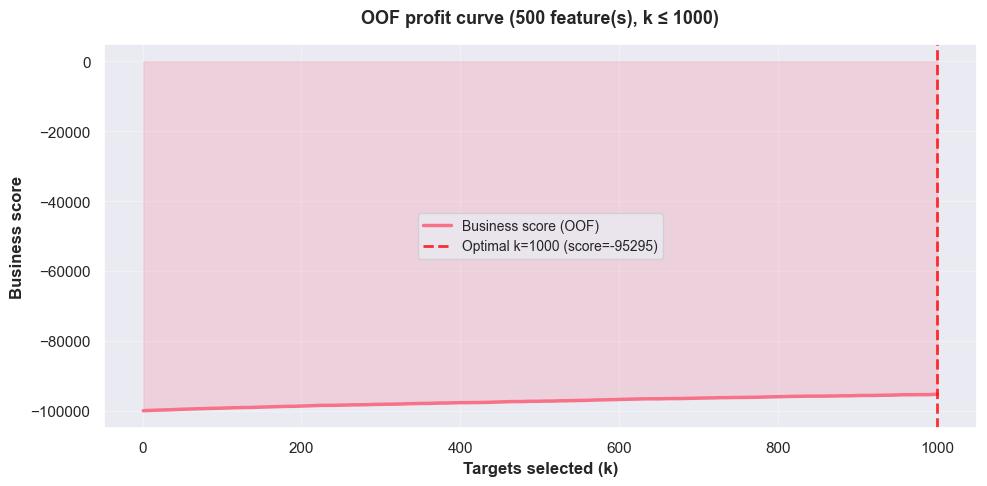

In [7]:
fig = plot_topk_oof_profit_curve(profit_curve, n_features, DEFAULT_MAX_TARGETS)
plt.show()

In [8]:
threshold_config = {
    "model": "logistic_500feat",
    "optimal_k": int(profit_curve.best_k),
    "optimal_threshold": float(profit_curve.best_threshold),
    "business_score": float(profit_curve.best_score),
    "tp": int(best_row["tp"]),
    "fp": int(best_row["fp"]),
    "feature_count": int(n_features),
    "C": float(best_c),
}

threshold_path = OUTPUTS_PATH / "optimal_threshold.json"
with threshold_path.open("w", encoding="utf-8") as f:
    json.dump(threshold_config, f, indent=2)

print(f"Saved {threshold_path.relative_to(PROJECT_ROOT)}")

Saved outputs/optimal_threshold.json
